# Task 1: Language model inference

The goal if this first task is to familiarize yourself with the huggingface transformers and dataset libraries. You will learn how to load and tokenize a dataset, how to load a pre-trained language model, and finally, how to run a model in inference mode.

Your task is to complete the missing code blocks below.

In [ ]:
!pip install datasets evaluate transformers[sentencepiece] torch matplotlib

In [2]:
# import dependencies
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from datasets import load_dataset, load_dataset_builder, get_dataset_split_names, get_dataset_config_names
from transformers import XGLMTokenizer, XGLMTokenizerFast, XGLMForCausalLM, AutoModelForCausalLM, AutoTokenizer, GenerationConfig

In [3]:
print(torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# Check if CUDA (GPU support) is available
if torch.cuda.is_available():
    print("CUDA (GPU support) is available and enabled!")
    default_device = torch.device("cuda") # Set the device to GPU 1
else:
    print("CUDA (GPU support) is not available. Using CPU.")
    default_device = torch.device("cpu")

print(default_device)

1
Tesla T4
CUDA (GPU support) is available and enabled!
cuda


## Explore dataset

In [4]:
DATA_SET_NAME = "facebook/flores" # specify dataset name
MODEL_NAME = "facebook/xglm-564M" # specify model name
# MODEL_NAME = "gpt2" # specify model name

In [5]:
# Explore a dataset

# covered language codes can be found here: https://github.com/openlanguagedata/flores?tab=readme-ov-file#language-coverage

ds_builder = load_dataset_builder("facebook/flores", "deu_Latn", trust_remote_code=True)
print(ds_builder.info.description) # print the dataset description

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The creation of FLORES-200 doubles the existing language coverage of FLORES-101. 
Given the nature of the new languages, which have less standardization and require 
more specialized professional translations, the verification process became more complex. 
This required modifications to the translation workflow. FLORES-200 has several languages 
which were not translated from English. Specifically, several languages were translated 
from Spanish, French, Russian and Modern Standard Arabic. Moreover, FLORES-200 also 
includes two script alternatives for four languages. FLORES-200 consists of translations 
from 842 distinct web articles, totaling 3001 sentences. These sentences are divided 
into three splits: dev, devtest, and test (hidden). On average, sentences are approximately 
21 words long.



In [ ]:
# print the features (columns) of the dataset
print(ds_builder.info.features)

{'id': Value(dtype='int32', id=None), 'URL': Value(dtype='string', id=None), 'domain': Value(dtype='string', id=None), 'topic': Value(dtype='string', id=None), 'has_image': Value(dtype='int32', id=None), 'has_hyperlink': Value(dtype='int32', id=None), 'sentence': Value(dtype='string', id=None)}


In [ ]:
# get the available splits
split_names = get_dataset_split_names(DATA_SET_NAME, config_name='deu_Latn', trust_remote_code=True)
print("Available splits:", split_names)

Available splits: ['dev', 'devtest']


## Load data, tokenize, and batchify

In [6]:
# specify languages
LANGUAGES = [
    "eng_Latn",
    "spa_Latn",
    "ita_Latn",
    "deu_Latn",
    "arb_Arab",
    "tel_Telu",
    "tam_Taml",
    "quy_Latn"
]

In [7]:
# load flores data for each language
datasets = {}
for lang in LANGUAGES:
    dataset = load_dataset(DATA_SET_NAME, lang, trust_remote_code=True)
    datasets[lang] = dataset

Generating dev split: 0 examples [00:00, ? examples/s]

Generating devtest split: 0 examples [00:00, ? examples/s]

Generating dev split: 0 examples [00:00, ? examples/s]

Generating devtest split: 0 examples [00:00, ? examples/s]

Generating dev split: 0 examples [00:00, ? examples/s]

...

Generating devtest split: 0 examples [00:00, ? examples/s]

Generating dev split: 0 examples [00:00, ? examples/s]

Generating devtest split: 0 examples [00:00, ? examples/s]

Generating dev split: 0 examples [00:00, ? examples/s]

Generating devtest split: 0 examples [00:00, ? examples/s]

In [8]:
# let's look at the English subset
english_dataset = datasets["eng_Latn"]

# Print some examples from the English subset
print(english_dataset)

DatasetDict({
    dev: Dataset({
        features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
        num_rows: 997
    })
    devtest: Dataset({
        features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
        num_rows: 1012
    })
})


In [9]:
# let's look at an individal sample from the dataset
sample_dev = next(iter(english_dataset['dev']))
print(sample_dev)

sample_devtest = next(iter(english_dataset['devtest']))
print(sample_devtest)

{'id': 1, 'URL': 'https://en.wikinews.org/wiki/Scientists_say_new_medical_diagnostic_chip_can_sort_cells_anywhere_with_an_inkjet', 'domain': 'wikinews', 'topic': 'health', 'has_image': 0, 'has_hyperlink': 0, 'sentence': 'On Monday, scientists from the Stanford University School of Medicine announced the invention of a new diagnostic tool that can sort cells by type: a tiny printable chip that can be manufactured using standard inkjet printers for possibly about one U.S. cent each.'}
{'id': 1, 'URL': 'https://en.wikinews.org/wiki/Toronto_team-led_research_on_Type_1_Diabetes_%27groundbreaking%27', 'domain': 'wikinews', 'topic': 'disease, research, canada', 'has_image': 0, 'has_hyperlink': 0, 'sentence': '"We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.'}


In [10]:
# tokenize the data

# load a pre-trained tokenizer from the huggingface hub
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side='left')

# gpt2 does not have a padding token, so we have to add it manually
if MODEL_NAME == "gpt2":
    tokenizer.add_special_tokens({'pad_token': tokenizer.unk_token})

# Specify the tokenization function
def tokenization(example):
    return tokenizer(example['sentence'], padding=True, truncation=True)

tokenizer_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.92M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

In [11]:
# let's take a look at a tokenized sample
# Tokenize the dataset
tokenized_dataset = english_dataset['dev'].map(tokenization, batched=True, remove_columns=['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'])
print(next(iter(tokenized_dataset)))

Map:   0%|          | 0/997 [00:00<?, ? examples/s]

{'input_ids': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1504, 28488, 4, 140003, 501, 32, 200884, 6073, 9512, 48, 88230, 76168, 32, 160597, 48, 11, 929, 55516, 35761, 155, 490, 9482, 89288, 235, 6950, 13, 11, 61368, 24049, 2005, 37295, 155, 490, 113, 213481, 72, 1117, 5885, 86368, 6929, 111288, 7, 73, 59298, 769, 743, 242, 5, 211, 5, 19015, 5129, 5], 'attention_mask': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [12]:
# construct a pytorch data loader for each dataset
BATCH_SIZE = 2 # for testing purposes, we start with a batch size of 2. You can change this later.

# Construct a PyTorch DataLoader for each dataset
dataloaders = {
    lang: {
        'dev': DataLoader(dataset['dev'], batch_size=BATCH_SIZE, shuffle=True),
        'devtest': DataLoader(dataset['devtest'], batch_size=BATCH_SIZE, shuffle=True)
    } for lang, dataset in datasets.items()
}

In [ ]:
# Example: accessing the DataLoader for English dataset
english_dataloader = dataloaders["eng_Latn"]
print(next(iter(english_dataloader['dev'])))

{'id': tensor([327, 864]), 'URL': ['https://en.wikinews.org/wiki/Tropical_Storm_Danielle_forms_in_Atlantic_Ocean', 'https://en.wikivoyage.org/wiki/Travellers%27_diarrhea'], 'domain': ['wikinews', 'wikivoyage'], 'topic': ['Disasters and accidents', 'travel, safety'], 'has_image': tensor([0, 0]), 'has_hyperlink': tensor([0, 0]), 'sentence': ['As the storm is far from landfall, it remains difficult to assess potential impact to the United States or Caribbean.', 'Also, in warmer climates bacteria both grow more quickly and survive longer outside the body.']}


## Load model

In [ ]:
# load pre-trained model from the huggingface hub
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# put the model into evaluation mode
model.eval().to(default_device)

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

XGLMForCausalLM(
  (model): XGLMModel(
    (embed_tokens): Embedding(256008, 1024, padding_idx=1)
    (embed_positions): XGLMSinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-23): 24 x XGLMDecoderLayer(
        (self_attn): XGLMAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (activation_fn): GELUActivation()
        (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      )
    )
    (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine

In [ ]:
# Store per-batch losses for each language
losses = {lang: [] for lang in LANGUAGES}

# Iterate over the dataset for each language and compute the cross-entropy loss per batch

for lang, dataloader in dataloaders.items():
    dev_dataloader = dataloader['dev']
    loss = 0
    for batch in dev_dataloader:
        # Tokenize the sentences in the batch
        raw_data = batch['sentence']
        inputs = tokenizer(raw_data, padding=True, truncation=True, return_tensors="pt")

        # get the input ids
        input_ids = inputs["input_ids"].to(default_device)

        # attention mask either holds a value of 0 or 1 depending on
        # if the token is a padded one or not.
        attention_mask = inputs["attention_mask"]

        # we need to put a label of -100 for the padded parts
        labels = input_ids.clone().to(default_device)
        labels[attention_mask == 0] = -100

        # pass the input ids and labels to the model
        with torch.no_grad():
            outputs = model(input_ids=input_ids, labels=labels)
            loss += outputs.loss

    # Store the loss
    losses[lang] = loss / len(dev_dataloader)

# Example: Printing the average loss for each language
for lang, loss in losses.items():
    print(f"Average loss for {lang}: {loss}")

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Average loss for eng_Latn: 5.955739974975586
Average loss for spa_Latn: 5.506968021392822
Average loss for ita_Latn: 5.524467945098877
Average loss for deu_Latn: 5.548660755157471
Average loss for arb_Arab: 5.280261993408203
Average loss for tel_Telu: 4.798930644989014
Average loss for tam_Taml: 4.744004726409912
Average loss for quy_Latn: 7.3186821937561035


## Visualize loss per language

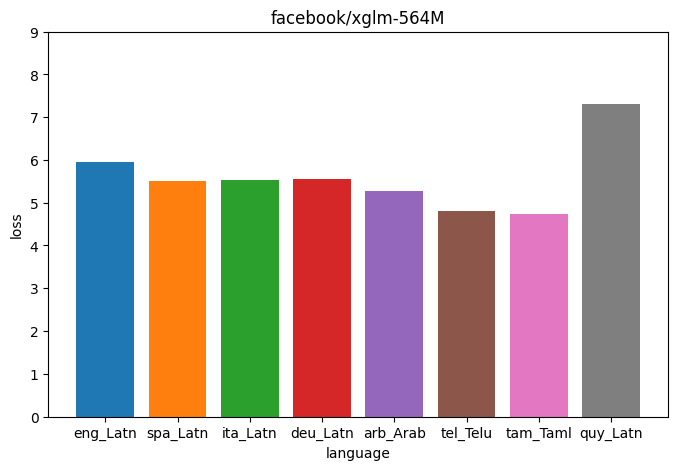

In [ ]:
# create a figure
fig, axes = plt.subplots(figsize=(8, 5))

# Convert losses to NumPy arrays
losses_np = {lang: loss.cpu().numpy() for lang, loss in losses.items()}

# create a bar plot for each langauge
for i, (lang, loss) in enumerate(losses_np.items()):
    axes.bar(i, loss, label=lang)

# format plot
axes.set_xlabel("language") # x-axis label
axes.set_xticks(range(len(LANGUAGES))) # x-axis ticks
axes.set_xticklabels(losses.keys()) # x-axis tick labels
axes.set_ylabel("loss") # y-axis label
axes.set_ylim(0, 9) # range of y-axis
axes.set_title(MODEL_NAME); # title

## Comparing XGLM to GPT2

Your next task is to re-run the analysis above, but using `gpt2` as the pre-trained language model. For this exercise, focus on your native language, unless it's English or isn't covered by flores. In that case, pick another language that you can read well.

Compare the language modeling loss of XGLM and GPT2. What do you observe? Investigate the differences in tokenization for XGLM and GPT2. What do you observe? How can the good (or bad) performance of GPT2 be explained?

### Losses on the gpt2 model

In [13]:
MODEL_NAME_gpt = "gpt2"

# load pre-trained model from the huggingface hub
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME_gpt)

# put the model into evaluation mode
model.eval().to(default_device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [14]:
# load a pre-trained tokenizer from the huggingface hub
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_gpt, padding_side='left')

# gpt2 does not have a padding token, so we have to add it manually
if MODEL_NAME_gpt == "gpt2":
    tokenizer.add_special_tokens({'pad_token': tokenizer.unk_token})

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [15]:
# Store per-batch losses for each language
losses_gpt = {lang: [] for lang in LANGUAGES}

# Iterate over the dataset for each language and compute the cross-entropy loss per batch

for lang, dataloader in dataloaders.items():
    dev_dataloader = dataloader['dev']
    loss = 0
    for batch in dev_dataloader:
        # Tokenize the sentences in the batch
        raw_data = batch['sentence']
        inputs = tokenizer(raw_data, padding=True, truncation=True, return_tensors="pt")

        # get the input ids
        input_ids = inputs["input_ids"].to(default_device)

        # attention mask either holds a value of 0 or 1 depending on
        # if the token is a padded one or not.
        attention_mask = inputs["attention_mask"]

        # we need to put a label of -100 for the padded parts
        labels = input_ids.clone().to(default_device)
        labels[attention_mask == 0] = -100

        # pass the input ids and labels to the model
        with torch.no_grad():
            outputs = model(input_ids=input_ids, labels=labels)
            loss += outputs.loss

    # Store the loss
    losses_gpt[lang] = loss / len(dev_dataloader)

# Example: Printing the average loss for each language
for lang, loss in losses_gpt.items():
    print(f"Average loss for {lang}: {loss}")

Average loss for eng_Latn: 3.887058973312378
Average loss for spa_Latn: 5.045995712280273
Average loss for ita_Latn: 5.647487640380859
Average loss for deu_Latn: 4.772602558135986
Average loss for arb_Arab: 2.545302629470825
Average loss for tel_Telu: 1.3881874084472656
Average loss for tam_Taml: 1.2204707860946655
Average loss for quy_Latn: 6.527773380279541


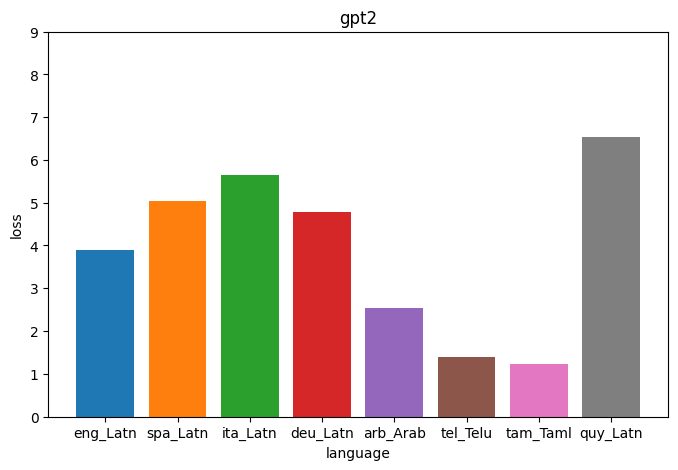

In [17]:
# create a figure
fig, axes = plt.subplots(figsize=(8, 5))

# Convert losses to NumPy arrays
losses_np = {lang: loss.cpu().numpy() for lang, loss in losses_gpt.items()}

# create a bar plot for each langauge
for i, (lang, loss) in enumerate(losses_np.items()):
    axes.bar(i, loss, label=lang)

# format plot
axes.set_xlabel("language") # x-axis label
axes.set_xticks(range(len(LANGUAGES))) # x-axis ticks
axes.set_xticklabels(losses_np.keys()) # x-axis tick labels
axes.set_ylabel("loss") # y-axis label
axes.set_ylim(0, 9) # range of y-axis
axes.set_title(MODEL_NAME_gpt); # title

### Native Language

In [ ]:
# Specify your native language
NATIVE_LANGUAGE = "guj_Gujr"  # Replace with your native language code

# Load the dataset for your native language
native_dataset = load_dataset(DATA_SET_NAME, NATIVE_LANGUAGE, trust_remote_code=True)

# Tokenize the dataset using XGLM tokenizer
xglm_tokenizer = XGLMTokenizer.from_pretrained(MODEL_NAME, padding_side='left')

# Tokenize the dataset using GPT2 tokenizer
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2", padding_side='left')
gpt2_tokenizer.add_special_tokens({'pad_token': gpt2_tokenizer.unk_token})

# Construct PyTorch DataLoaders for native dataset
native_dataloader = DataLoader(native_dataset['dev'], batch_size=2, shuffle=True)

# Load the pre-trained xglm model
xglm_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
xglm_model.eval().to(default_device)

# Load the pre-trained GPT2 model
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2")
gpt2_model.eval().to(default_device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
# Compute the language modeling loss for XGLM
xglm_loss = 0
for batch in native_dataloader:
    # Tokenize the sentences in the batch
    raw_data = batch['sentence']
    inputs = xglm_tokenizer(raw_data, padding=True, truncation=True, return_tensors="pt")

    # get the input ids
    input_ids = inputs["input_ids"].to(default_device)
    attention_mask = inputs["attention_mask"]

    # Generate labels
    labels = input_ids.clone().to(default_device)
    labels[attention_mask == 0] = -100

    # Forward pass to compute the loss
    with torch.no_grad():
        outputs = xglm_model(input_ids, labels=labels)
        xglm_loss += outputs.loss

avg_xglm_loss = xglm_loss / len(native_dataloader)

# Compute the language modeling loss for GPT2
gpt2_loss = 0
for batch in native_dataloader:
    # Tokenize the sentences in the batch
    raw_data = batch['sentence']
    inputs = gpt2_tokenizer(raw_data, padding=True, truncation=True, return_tensors="pt")

    # get the input ids
    input_ids = inputs["input_ids"].to(default_device)
    attention_mask = inputs["attention_mask"]

    # Generate labels
    labels = input_ids.clone().to(default_device)
    labels[attention_mask == 0] = -100

    # Forward pass to compute the loss
    with torch.no_grad():
        outputs = gpt2_model(input_ids, labels=labels)
        gpt2_loss += outputs.loss

avg_gpt2_loss = gpt2_loss / len(native_dataloader)


In [ ]:
print(f"Loss on {NATIVE_LANGUAGE} for XGLM: {avg_xglm_loss}")
print(f"Loss on {NATIVE_LANGUAGE} for gpt2: {avg_gpt2_loss}")

Loss on guj_Gujr for XGLM: 10.849505424499512
Loss on guj_Gujr for gpt2: 1.4869853258132935


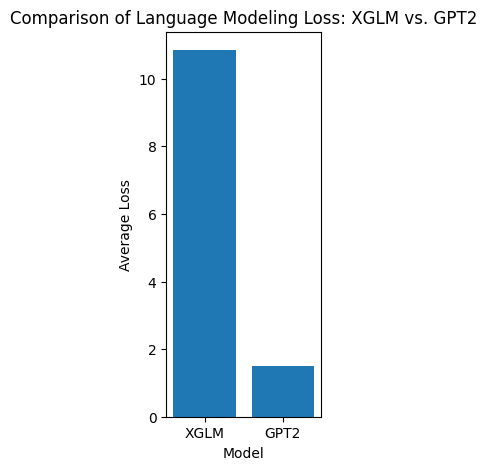

In [ ]:
# Visualize and compare the losses
fig, axes = plt.subplots(figsize=(2, 5))

xglm_losses = avg_xglm_loss.cpu().numpy()
gpt2_losses = avg_gpt2_loss.cpu().numpy()

axes.bar(["XGLM", "GPT2"], [xglm_losses, gpt2_losses])
axes.set_xlabel("Model")
axes.set_ylabel("Average Loss")
axes.set_title("Comparison of Language Modeling Loss: XGLM vs. GPT2")
plt.show()

In [ ]:
model_inputs = gpt2_tokenizer(["જીવન એક દોડ છે", "ભારત એ"], return_tensors="pt", padding=True).to(default_device)

generated_ids = gpt2_model.generate(**model_inputs, max_length=50)

gpt2_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


['જીવન એક દોડ છેનનનન�', 'ભારત એરતનન�']

- Tokenization Differences:
    - XGLM Tokenization: XGLM tokenization may follow specific tokenization strategies optimized for the XGLM model architecture. It may handle certain linguistic features or special tokens differently than other tokenizers.
    - GPT2 Tokenization: GPT2 tokenization follows standard tokenization techniques used in transformer-based models. It segments text into subwords and applies common tokenization methods such as lowercasing, punctuation handling, and special token addition.
    
    The differences in tokenization may result in variations in how tokens are represented and processed by the respective models.

- Performance Explanation for GPT2:
    - GPT2 is a large-scale transformer-based language model trained on a vast corpus of text from the internet. It has a sophisticated architecture capable of capturing complex language patterns and dependencies effectively.
    - Additionally, GPT2 benefits from extensive pre-training on diverse datasets, which allows it to generalize well to various languages and tasks.
    - The significantly lower language modeling loss observed for GPT2 in this comparison further supports its superior performance in modeling the language structure and making accurate predictions.